In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

try:
    df_accidents = pd.read_csv("dataset_accidents.csv")
except FileNotFoundError:
    url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
    header = {'Accept': 'application/vnd.sdmx.data+csv;version=1.0.0'}
    df_accidents = pd.read_csv(url, storage_options=header)
    df_accidents.to_csv("dataset_accidents.csv", index=False)

ISTAT Dataset Cleaning

In [3]:
df_accidents = pd.read_csv("dataset_accidents.csv")

df_accidents.info()

df_accidents["TIME_PERIOD"].unique()

print("Valori unici in DATA_TYPE:")
print(df_accidents["DATA_TYPE"].unique())

print("\nValori unici in RESULT:")
print(df_accidents["RESULT"].unique())

empty_columns = ["OBS_STATUS", "NOTE_DS", "NOTE_REF_AREA", "NOTE_DATA_TYPE", "NOTE_RESULT",
                 "NOTE_TIME_PERIOD", "BASE_PER", "UNIT_MEAS", "UNIT_MULT"]
df_accidents = df_accidents.drop(columns = empty_columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          573552 non-null  object 
 1   FREQ              573552 non-null  object 
 2   REF_AREA          573552 non-null  int64  
 3   DATA_TYPE         573552 non-null  object 
 4   RESULT            573552 non-null  object 
 5   TIME_PERIOD       573552 non-null  int64  
 6   OBS_VALUE         573552 non-null  int64  
 7   OBS_STATUS        0 non-null       float64
 8   NOTE_DS           0 non-null       float64
 9   NOTE_REF_AREA     0 non-null       float64
 10  NOTE_DATA_TYPE    0 non-null       float64
 11  NOTE_RESULT       0 non-null       float64
 12  NOTE_TIME_PERIOD  0 non-null       float64
 13  BASE_PER          0 non-null       float64
 14  UNIT_MEAS         0 non-null       float64
 15  UNIT_MULT         0 non-null       float64
dtypes: float64(9), int64

In [4]:
test_killinj = df_accidents[
    (df_accidents["REF_AREA"] == 1001) & 
    (df_accidents["TIME_PERIOD"] == 2001) & 
    (df_accidents["DATA_TYPE"] == "KILLINJ")]

print(test_killinj[["RESULT", "OBS_VALUE"]])

   RESULT  OBS_VALUE
0       F         10
24      M          0


In [5]:
test_roadacc = df_accidents[
    (df_accidents["REF_AREA"] == 1001) & 
    (df_accidents["TIME_PERIOD"] == 2001) & 
    (df_accidents["DATA_TYPE"] == "ROADACC")]

print(test_roadacc[["RESULT", "OBS_VALUE"]])

   RESULT  OBS_VALUE
48      9          5


SITUAS Dataset Cleaning

In [6]:
df_situas = pd.read_csv("dataset_situas_2024.csv", sep=";")

#df_situas.info()

situas_columns = ["Codice Provincia/Uts", "Codice Comune (numerico)", "Comune",
                  "Sigla automobilistica", "Superficie (Kmq)", "Popolazione residente"]
df_situas_clean = df_situas[situas_columns].copy()

df_situas_clean = df_situas_clean.dropna(subset = ["Comune"])

df_situas_clean["Superficie (Kmq)"] = df_situas_clean["Superficie (Kmq)"].str.replace(",", ".")
df_situas_clean["Superficie (Kmq)"] = pd.to_numeric(df_situas_clean["Superficie (Kmq)"], errors='coerce')

df_situas_clean = df_situas_clean.dropna(subset = ["Superficie (Kmq)"])

df_situas_clean["Sigla automobilistica"] = df_situas_clean.groupby("Codice Provincia/Uts")["Sigla automobilistica"].ffill().bfill()

df_situas_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7894 entries, 0 to 7895
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Codice Provincia/Uts      7894 non-null   int64  
 1   Codice Comune (numerico)  7894 non-null   int64  
 2   Comune                    7894 non-null   object 
 3   Sigla automobilistica     7894 non-null   object 
 4   Superficie (Kmq)          7894 non-null   float64
 5   Popolazione residente     7894 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 431.7+ KB


We chose to use the Resident Population (updated to 2024) instead of the Legal Population (based on the 2021 census) because, for a current road risk analysis, it is preferable to relate the accidents to the actual number of people present in the territory in recent years.

ISTAT Dataset Outliers Analysis

count    191184.000000
mean         24.997599
std         257.519973
min           0.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       23135.000000
Name: OBS_VALUE, dtype: float64


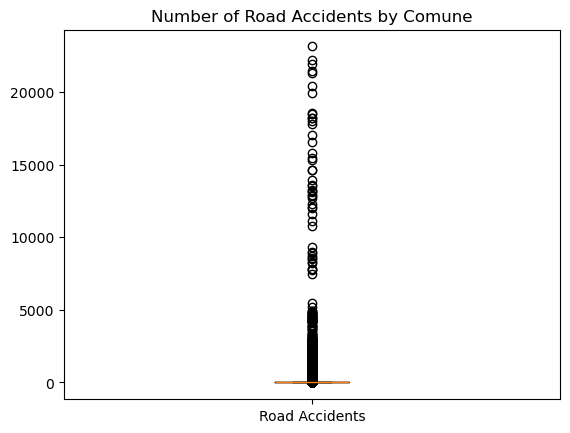

In [7]:
df_roadacc = df_accidents[df_accidents["DATA_TYPE"] == "ROADACC"].copy()
print(df_roadacc["OBS_VALUE"].describe())
plt.boxplot(df_roadacc["OBS_VALUE"], tick_labels = ["Road Accidents"])
plt.title("Number of Road Accidents by Comune")
plt.show()

SITUAS Dataset Outliers Analysis

count    7.894000e+03
mean     7.117876e+03
std      2.783960e+04
min      3.200000e+01
25%      9.690000e+02
50%      2.382000e+03
75%      6.237500e+03
max      1.365698e+06
Name: Popolazione residente, dtype: float64
count    7894.000000
mean       38.104477
std        48.843523
min         0.122200
25%        11.465275
50%        22.446950
75%        44.744225
max       653.674800
Name: Superficie (Kmq), dtype: float64


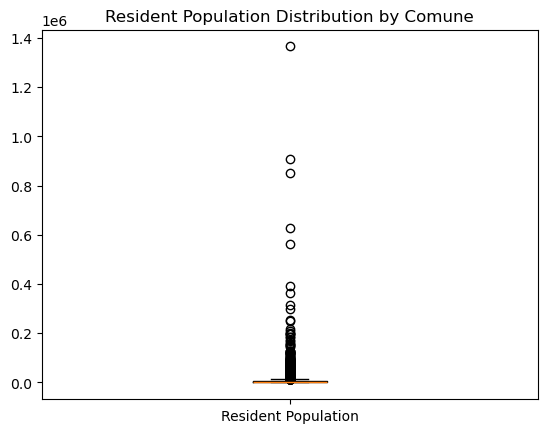

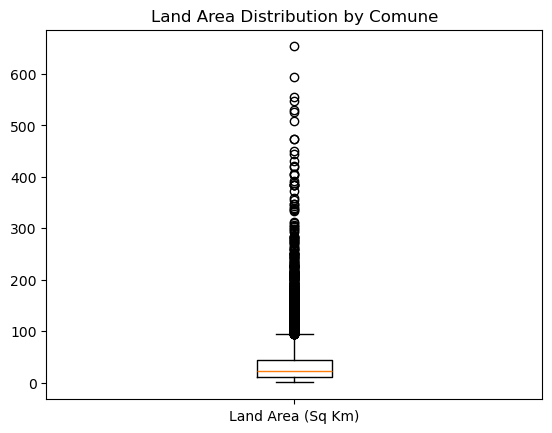

In [8]:
print(df_situas_clean["Popolazione residente"].describe())

print(df_situas_clean["Superficie (Kmq)"].describe())

plt.boxplot(df_situas_clean["Popolazione residente"], tick_labels=["Resident Population"])
plt.title("Resident Population Distribution by Comune")
plt.show()

plt.boxplot(df_situas_clean["Superficie (Kmq)"], tick_labels=["Land Area (Sq Km)"])
plt.title("Land Area Distribution by Comune")
plt.show()

Merging ISTAT Dataset and SITUAS Dataset

In [9]:
df_merged = pd.merge(df_roadacc, df_situas_clean, left_on = "REF_AREA", right_on = "Codice Comune (numerico)",
                     how = "inner")

df_merged.info()

df_merged["Superficie (Kmq)"] = df_merged["Superficie (Kmq)"].round(2)

df_merged = df_merged.drop(columns=["DATAFLOW", "FREQ", "Codice Comune (numerico)"])

df_merged.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182521 entries, 0 to 182520
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   DATAFLOW                  182521 non-null  object 
 1   FREQ                      182521 non-null  object 
 2   REF_AREA                  182521 non-null  int64  
 3   DATA_TYPE                 182521 non-null  object 
 4   RESULT                    182521 non-null  object 
 5   TIME_PERIOD               182521 non-null  int64  
 6   OBS_VALUE                 182521 non-null  int64  
 7   Codice Provincia/Uts      182521 non-null  int64  
 8   Codice Comune (numerico)  182521 non-null  int64  
 9   Comune                    182521 non-null  object 
 10  Sigla automobilistica     182521 non-null  object 
 11  Superficie (Kmq)          182521 non-null  float64
 12  Popolazione residente     182521 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory us

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Provincia/Uts,Comune,Sigla automobilistica,Superficie (Kmq),Popolazione residente
0,1001,ROADACC,9,2001,5,201,Agliè,TO,13.15,2585
1,1001,ROADACC,9,2002,5,201,Agliè,TO,13.15,2585
2,1001,ROADACC,9,2003,4,201,Agliè,TO,13.15,2585
3,1001,ROADACC,9,2004,9,201,Agliè,TO,13.15,2585
4,1001,ROADACC,9,2005,2,201,Agliè,TO,13.15,2585


In [10]:
df_merged["Accident_Rate"] = (df_merged["OBS_VALUE"] / df_merged["Popolazione residente"]) * 1000

df_merged["Accident_Density_per_SqKm"] = df_merged["OBS_VALUE"] / df_merged["Superficie (Kmq)"]

df_merged.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Provincia/Uts,Comune,Sigla automobilistica,Superficie (Kmq),Popolazione residente,Accident_Rate,Accident_Density_per_SqKm
0,1001,ROADACC,9,2001,5,201,Agliè,TO,13.15,2585,1.934236,0.380228
1,1001,ROADACC,9,2002,5,201,Agliè,TO,13.15,2585,1.934236,0.380228
2,1001,ROADACC,9,2003,4,201,Agliè,TO,13.15,2585,1.547389,0.304183
3,1001,ROADACC,9,2004,9,201,Agliè,TO,13.15,2585,3.481625,0.684411
4,1001,ROADACC,9,2005,2,201,Agliè,TO,13.15,2585,0.773694,0.152091


We chose to use the 2024 Resident Population for all previous years because, for a historical analysis aimed at future investments, it is preferable to relate past accidents to the current dimension and scale of each Comune.

Clustering with K-Means

We focused our Clustering analysis on the year 2024, as it is the most recent year for which complete data are available. Furthermore, we excluded all Comuni with a Resident Population below 10,000 because these are not sustainable from a business perspective.

In [11]:
df_clustering = df_merged[(df_merged["TIME_PERIOD"] == 2024) & (df_merged["Popolazione residente"] >= 10000)].copy()

df_clustering.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1201 entries, 166 to 182434
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   REF_AREA                   1201 non-null   int64  
 1   DATA_TYPE                  1201 non-null   object 
 2   RESULT                     1201 non-null   object 
 3   TIME_PERIOD                1201 non-null   int64  
 4   OBS_VALUE                  1201 non-null   int64  
 5   Codice Provincia/Uts       1201 non-null   int64  
 6   Comune                     1201 non-null   object 
 7   Sigla automobilistica      1201 non-null   object 
 8   Superficie (Kmq)           1201 non-null   float64
 9   Popolazione residente      1201 non-null   int64  
 10  Accident_Rate              1201 non-null   float64
 11  Accident_Density_per_SqKm  1201 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 122.0+ KB


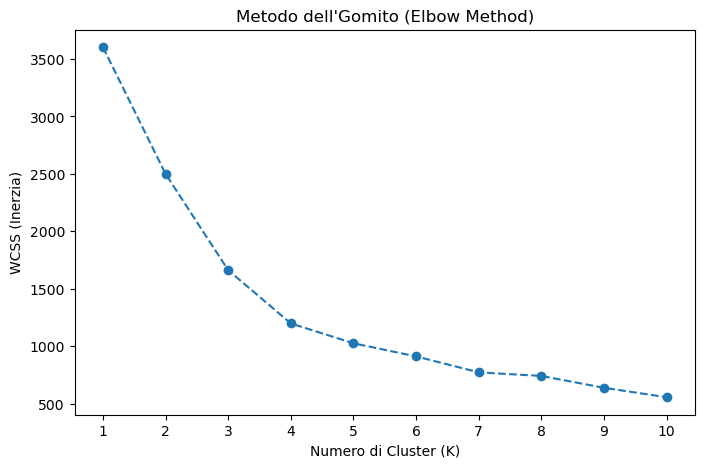

In [13]:
features = ["Popolazione residente", "Accident_Rate", "Accident_Density_per_SqKm"]
X = df_clustering[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--")
plt.title("Metodo dell'Gomito (Elbow Method)")
plt.xlabel("Numero di Cluster (K)")
plt.ylabel("WCSS (Inerzia)")
plt.xticks(range(1, 11))
plt.show()

We chose Number of Cluster K = 4

In [20]:
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=42)
df_clustering["Cluster"] = kmeans.fit_transform(X_scaled).argmax(axis=1)

df_clustering["Cluster"] = kmeans.labels_

cluster_profiles = df_clustering.groupby("Cluster")[features].mean()

cluster_profiles = cluster_profiles.rename(
        columns={ "Popolazione residente": "Average_Population",
                  "Accident_Rate": "Average_Accident_Rate",
                  "Accident_Density_per_SqKm": "Average_Accident_Density"})

cluster_profiles["Comuni_Count"] = (
    df_clustering.groupby("Cluster")["Comune"].count())

cluster_profiles

,Average_Population,Average_Accident_Rate,Average_Accident_Density,Comuni_Count
Cluster,,,,
0,35556.658667,3.821711,2.339554,375
1,82599.059701,4.396636,12.227549,67
2,864136.000000,4.394351,23.040800,5
3,19947.912467,1.875426,1.384014,754
